In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/ai_prac/MLP_CNN"


/content/drive/.shortcut-targets-by-id/1ZfZ6vTDIAlio0lSllFn4Y0RHpqbrdv46/ai_prac/MLP_CNN


In [3]:
import torch
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
  print(torch.cuda.get_device_name(0))

cuda: True
NVIDIA A100-SXM4-40GB


In [4]:
# ## LOAD and resume training
# !python -m race2048.train_dqn --load checkpoints/dqn_cnn_n3.pt \
#   --strong-board-cnn --steps 500000 --device cuda \
#   --reset-epsilon-on-load --eps-decay-steps 300000 --eps-end 0.02 --lr 3e-5 \
#   --save checkpoints/dqn_cnn_n3_ft.pt \
#   --metrics-csv checkpoints/dqn_cnn_n3.pt

In [ ]:
!python -m race2048.train_dqn --load checkpoints/dqn_cnn_n3_1.pt --steps 800000 \
  --save checkpoints/dqn_cnn_n3_1.pt --metrics-csv checkpoints/dqn_cnn_n3_1.pt.csv

Note: resuming uses qnet_config from checkpoint {'qnet_type': 'cnn', 'state_dim': 16, 'action_dim': 4, 'hidden_dim': 256, 'num_hidden_layers': 2, 'layer_norm': False, 'cnn_channels': (64, 128, 128)} (CLI --hidden-dim / --qnet-hidden-layers / --qnet-layernorm / --qnet-type ignored).
Loaded checkpoints/dqn_cnn_n3_1.pt — resume env_steps=7500000, train_steps=7496985
Note: replay buffer is not in the checkpoint; it refills from scratch (capacity 100000). Gradients use random subsets until buffer grows.
Metrics CSV: /content/drive/.shortcut-targets-by-id/1ZfZ6vTDIAlio0lSllFn4Y0RHpqbrdv46/ai_prac/MLP_CNN/checkpoints/dqn_cnn_n3_1.pt.csv
env_step 7510000/8300000  eps 0.010  buffer 10000  grad 7506858  mean_loss_2000 1.2161  ep 24  58s
episode 50  env_step 7518605/8300000  eps 0.010  last_50ep: win% 0.0  mean_return 921.38  mean_len 372.1  mean_max_tile 393  best_max_tile 1024  mean_loss_2000 1.3482  buffer 18605  109s
env_step 7520000/8300000  eps 0.010  buffer 20000  grad 7516858  mean_loss_2

In [8]:
!python -m race2048.eval_cli dqn \
  --checkpoint checkpoints/dqn_cnn_n3_1.pt \
  --episodes 2000 \
  --device cuda

Agent: dqn   episodes: 2000
Checkpoint: /content/drive/.shortcut-targets-by-id/1ZfZ6vTDIAlio0lSllFn4Y0RHpqbrdv46/ai_prac/MLP_CNN/checkpoints/dqn_cnn_n3_1.pt
Reach 2048 rate:       0.003
Mean moves to 2048:    1020.40   (median 1019.0)
Mean valid moves/game: 533.9
Mean max tile:         580.9


## GRAPHS

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "checkpoints/dqn_cnn_n3.csv"

df = pd.read_csv(CSV_PATH)
df.head()
df["event"].value_counts()

,event,wall_time_s,env_step,episode,epsilon,buffer_size,train_steps,mean_loss,loss_n_finite,loss_n_total,win_rate_pct,mean_return,mean_ep_len,mean_max_tile,best_max_tile
0,episode,146.142264,5774,50,0.989029,1941,3775,1.994515,2000,2000,0.0,234.367049,115.48,104.96,256.0
1,env_step,307.504551,10000,84,0.981000,3362,8001,2.394709,2000,2000,NaN,NaN,NaN,NaN,NaN
2,episode,382.770375,11944,100,0.977306,4017,9945,2.587951,2000,2000,0.0,253.943060,123.40,114.56,256.0
3,episode,620.222160,17905,150,0.965981,6023,15906,3.294329,2000,2000,0.0,243.948513,119.22,109.44,256.0
4,env_step,701.926417,20000,167,0.962000,6726,18001,3.479252,2000,2000,NaN,NaN,NaN,NaN,NaN


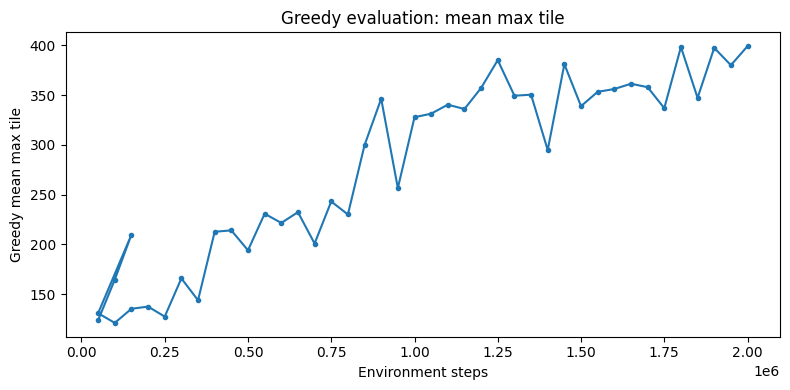

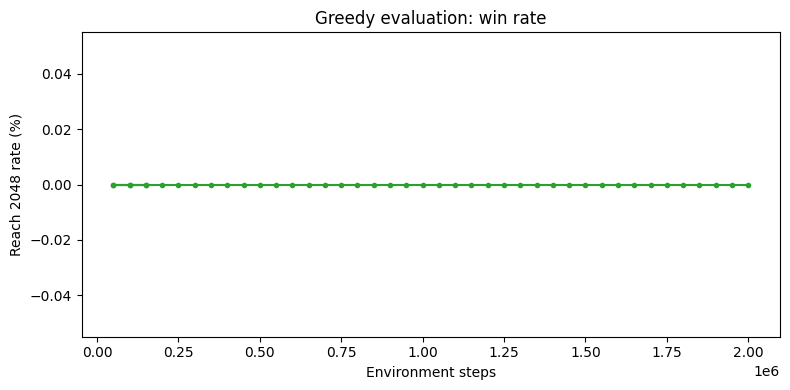

In [11]:
g = df[df["event"] == "greedy_eval"].copy()
g["env_step"] = pd.to_numeric(g["env_step"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g["env_step"], g["mean_max_tile"], marker="o", ms=3)
ax.set_xlabel("Environment steps")
ax.set_ylabel("Greedy mean max tile")
ax.set_title("Greedy evaluation: mean max tile")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g["env_step"], g["win_rate_pct"], marker="o", ms=3, color="tab:green")
ax.set_xlabel("Environment steps")
ax.set_ylabel("Reach 2048 rate (%)")
ax.set_title("Greedy evaluation: win rate")
plt.tight_layout()
plt.show()

In [12]:
cols = ["env_step", "win_rate_pct", "mean_max_tile", "mean_ep_len", "mean_loss", "train_steps"]
greedy_table = (
    df.loc[df["event"] == "greedy_eval", cols]
      .apply(pd.to_numeric, errors="coerce")
      .sort_values("env_step")
)
greedy_table

,env_step,win_rate_pct,mean_max_tile,mean_ep_len,mean_loss,train_steps
13,50000,0.0,123.680,141.460,5.539802,48001
62,50000,0.0,130.720,152.590,5.670962,48001
27,100000,0.0,164.416,181.220,6.458400,98001
76,100000,0.0,120.992,138.732,6.530971,98001
41,150000,0.0,209.632,216.618,6.661850,148001
90,150000,0.0,135.168,154.212,6.674973,148001
105,200000,0.0,137.376,162.352,6.607385,198001
119,250000,0.0,127.296,143.840,6.512917,248001
132,300000,0.0,165.728,178.586,6.328871,298001
146,350000,0.0,143.744,162.508,6.421335,348001


In [13]:
short = greedy_table.tail(6).round(2)

In [14]:
milestones = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]

def nearest_row(subdf, target):
    idx = (subdf["env_step"] - target).abs().idxmin()
    return subdf.loc[idx]

summary = pd.DataFrame([nearest_row(greedy_table, m) for m in milestones if greedy_table["env_step"].max() >= m])
summary.round(2)

,env_step,win_rate_pct,mean_max_tile,mean_ep_len,mean_loss,train_steps
299,1000000.0,0.0,327.68,325.91,5.79,998001.0
502,2000000.0,0.0,399.10,382.42,5.92,1998001.0


In [ ]:
import numpy as np

# Select 5 evenly spaced indices across the dataframe
indices = np.linspace(0, len(greedy_table) - 1, 5).astype(int)

# Extract the rows to create a 5-row progress table
progress_table = greedy_table.iloc[indices].round(2)
display(progress_table)
